# IPL 2026 Match Prediction & Analysis

**Local conda env:** `conda activate ipl` — select the **ipl** kernel. Data and models load from this project’s `Datasets/` and `Models/` (see `project_paths.py`).

Load the trained XGBoost model and predict winners for upcoming IPL 2026 matches with detailed analysis.

**Sections:**
1. Load Model & Data
2. Helper Functions
3. Predict a Single Match
4. Batch Predict (Full Matchday)
5. Update Dataset After Matches

## 1. Load Model & Data

In [2]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / 'project_paths.py').is_file():
        sys.path.insert(0, str(_p))
        break
from project_paths import ROOT, DATASET_DIR, MODEL_DIR

BASE_DIR = ROOT
print(f'Project root: {BASE_DIR}')

# Load model artifacts
model = joblib.load(MODEL_DIR / 'xgb_ipl_model.pkl')
feature_cols = joblib.load(MODEL_DIR / 'feature_columns.pkl')
team_name_map = joblib.load(MODEL_DIR / 'team_name_map.pkl')

# Load datasets
matches = pd.read_csv(DATASET_DIR / 'matches.csv')
matches.columns = matches.columns.str.strip().str.lower().str.replace(' ', '_')
deliveries = pd.read_csv(DATASET_DIR / 'deliveries.csv')
deliveries.columns = deliveries.columns.str.strip().str.lower().str.replace(' ', '_')
player_match_stats = pd.read_csv(DATASET_DIR / 'player_match_stats.csv')
player_stats = pd.read_csv(DATASET_DIR / 'player_stats.csv')

# Apply common column renames (same as training)
matches_col_map = {
    'match_id': 'id', 'matchid': 'id',
    'match_date': 'date', 'matchdate': 'date',
    'match_winner': 'winner', 'matchwinner': 'winner',
    'player_of_match': 'player_of_match', 'playerofmatch': 'player_of_match',
    'tosswin': 'toss_winner', 'tossdecision': 'toss_decision',
    'dl': 'dl_applied', 'dlapplied': 'dl_applied',
    'winbyrun': 'win_by_runs', 'winbyruns': 'win_by_runs',
    'winbywickets': 'win_by_wickets', 'winbywicket': 'win_by_wickets',
    'matchnumber': 'match_number',
}
deliveries_col_map = {
    'match_id': 'id', 'matchid': 'id',
    'over': 'overs', 'over_number': 'overs', 'ballnumber': 'ball_number', 'ball': 'ball_number',
    'batsmanrun': 'batsman_run', 'batsmanruns': 'batsman_run', 'batsman_runs': 'batsman_run',
    'batter_runs': 'batsman_run',
    'team_batting': 'batting_team', 'team_bowling': 'bowling_team',
    'extrarun': 'extra_run', 'extraruns': 'extra_run', 'extra_runs': 'extra_run',
    'totalrun': 'total_run', 'totalruns': 'total_run', 'total_runs': 'total_run',
    'iswicketdelivery': 'is_wicket', 'is_wicket_delivery': 'is_wicket',
    'playerout': 'player_out', 'player_dismissed': 'player_out',
    'dismissal_kind': 'kind', 'dismissalkind': 'kind',
    'fieldersinvolved': 'fielders_involved',
    'battingteam': 'batting_team', 'extratype': 'extra_type',
    'nonstriker': 'non_striker', 'non-striker': 'non_striker',
}
matches.rename(columns=matches_col_map, inplace=True)
deliveries.rename(columns=deliveries_col_map, inplace=True)

if 'date' not in matches.columns and 'match_date' in matches.columns:
    matches.rename(columns={'match_date': 'date'}, inplace=True)
if 'winner' not in matches.columns and 'match_winner' in matches.columns:
    matches.rename(columns={'match_winner': 'winner'}, inplace=True)
if 'is_wicket' in deliveries.columns:
    deliveries['is_wicket'] = deliveries['is_wicket'].astype(int)

# Standardize team names
for col in ['team1', 'team2', 'winner', 'toss_winner']:
    if col in matches.columns:
        matches[col] = matches[col].replace(team_name_map)
if 'team' in player_match_stats.columns:
    player_match_stats['team'] = player_match_stats['team'].replace(team_name_map)

matches['date'] = pd.to_datetime(matches['date'], errors='coerce')
player_match_stats['date'] = pd.to_datetime(player_match_stats['date'], errors='coerce')

# Build first-innings map
first_innings_map = {}
for mid, group in deliveries.groupby('id'):
    inn1 = group[group['innings'] == 1]
    if len(inn1) > 0 and 'batting_team' in inn1.columns:
        team = inn1['batting_team'].iloc[0]
        first_innings_map[mid] = team_name_map.get(team, team)

print(f'Model loaded: {type(model).__name__}')
print(f'Features: {len(feature_cols)}')
print(f'Matches in dataset: {len(matches)}')
print(f'Players tracked: {player_stats["player"].nunique()}')
print(f'\nReady to predict!')

Model loaded: XGBClassifier
Features: 31
Matches in dataset: 1169
Players tracked: 767

Ready to predict!


## 2. Helper Functions

In [3]:
IPL_2026_TEAMS = [
    'Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bengaluru',
    'Kolkata Knight Riders', 'Delhi Capitals', 'Sunrisers Hyderabad',
    'Rajasthan Royals', 'Punjab Kings', 'Lucknow Super Giants', 'Gujarat Titans'
]

def get_team_form(team, n=5):
    """Get recent form for a team."""
    valid = matches.dropna(subset=['winner'])
    team_m = valid[(valid['team1'] == team) | (valid['team2'] == team)].tail(n)
    if len(team_m) == 0:
        return 0.5, []
    wins = (team_m['winner'] == team).sum()
    results = []
    for _, r in team_m.iterrows():
        opponent = r['team2'] if r['team1'] == team else r['team1']
        result = 'W' if r['winner'] == team else 'L'
        results.append(f"{result} vs {opponent}")
    return wins / len(team_m), results

def get_h2h(team1, team2):
    """Get head-to-head record."""
    valid = matches.dropna(subset=['winner'])
    h2h = valid[
        ((valid['team1'] == team1) & (valid['team2'] == team2)) |
        ((valid['team1'] == team2) & (valid['team2'] == team1))
    ]
    t1_wins = (h2h['winner'] == team1).sum()
    t2_wins = (h2h['winner'] == team2).sum()
    return t1_wins, t2_wins, len(h2h)

def get_venue_stats(venue, team1, team2):
    """Get venue-level stats."""
    valid = matches.dropna(subset=['winner'])
    v = valid[valid['venue'] == venue]
    if len(v) == 0:
        return {'total_matches': 0, 'bat_first_win_pct': 0.5,
                'team1_venue_pct': 0.5, 'team2_venue_pct': 0.5}

    bat_first_wins = sum(1 for _, r in v.iterrows()
                         if first_innings_map.get(r['id']) == r['winner'])

    t1_v = v[(v['team1'] == team1) | (v['team2'] == team1)]
    t2_v = v[(v['team1'] == team2) | (v['team2'] == team2)]

    return {
        'total_matches': len(v),
        'bat_first_win_pct': bat_first_wins / len(v),
        'team1_venue_pct': (t1_v['winner'] == team1).mean() if len(t1_v) > 0 else 0.5,
        'team2_venue_pct': (t2_v['winner'] == team2).mean() if len(t2_v) > 0 else 0.5,
    }

def get_toss_venue_pct(venue):
    """Win rate for toss winners at this venue."""
    valid = matches.dropna(subset=['winner'])
    v = valid[valid['venue'] == venue]
    if len(v) == 0:
        return 0.5
    return (v['toss_winner'] == v['winner']).mean()

def get_player_team_strength(team, playing_xi=None, n_recent=3):
    """Compute team strength from player stats."""
    pms = player_match_stats.copy()
    team_data = pms[pms['team'] == team]

    if playing_xi is not None and len(playing_xi) > 0:
        squad = playing_xi
    else:
        recent_ids = team_data.drop_duplicates('id').nlargest(3, 'date')['id'].unique()
        squad = team_data[team_data['id'].isin(recent_ids)]['player'].unique()

    if len(squad) == 0:
        return _default_strength()

    squad_data = pms[pms['player'].isin(squad)]
    if len(squad_data) == 0:
        return _default_strength()

    pcum = squad_data.groupby('player').agg(
        total_runs=('runs_scored', 'sum'), total_balls=('balls_faced', 'sum'),
        total_dismissals=('dismissed', 'sum'), total_wickets=('wickets', 'sum'),
        total_rc=('runs_conceded', 'sum'), total_bb=('balls_bowled', 'sum'),
        matches=('id', 'nunique'),
    ).reset_index()

    pcum['batting_sr'] = (pcum['total_runs'] / pcum['total_balls'].replace(0, np.nan)) * 100
    pcum['batting_avg'] = pcum['total_runs'] / pcum['total_dismissals'].replace(0, np.nan)
    pcum['bowling_econ'] = pcum['total_rc'] / (pcum['total_bb'] / 6).replace(0, np.nan)
    pcum['bowling_sr'] = pcum['total_bb'] / pcum['total_wickets'].replace(0, np.nan)
    pcum['boundary_pct'] = squad_data.groupby('player')['boundary_pct'].mean().reindex(pcum['player']).values

    recent_forms = []
    for p in squad:
        pd_ = squad_data[squad_data['player'] == p].tail(n_recent)
        if len(pd_) > 0 and pd_['balls_faced'].sum() > 0:
            recent_forms.append({
                'batting_sr': (pd_['runs_scored'].sum() / pd_['balls_faced'].sum()) * 100,
                'bowling_econ': pd_['economy'].mean() if pd_['balls_bowled'].sum() > 0 else np.nan,
            })
    rdf = pd.DataFrame(recent_forms)

    new_count = 0
    for p in squad:
        if p not in pcum['player'].values or pcum[pcum['player'] == p]['matches'].values[0] <= 1:
            new_count += 1

    return {
        'avg_batting_sr': _safe(pcum['batting_sr'].mean(), 125.0),
        'avg_batting_avg': _safe(pcum['batting_avg'].mean(), 25.0),
        'avg_bowling_econ': _safe(pcum['bowling_econ'].mean(), 8.0),
        'avg_bowling_sr': _safe(pcum['bowling_sr'].mean(), 20.0),
        'total_experience': int(pcum['matches'].sum()),
        'new_player_count': new_count,
        'avg_boundary_pct': _safe(pcum['boundary_pct'].mean(), 0.5),
        'recent_batting_sr': _safe(rdf['batting_sr'].mean(), 125.0) if len(rdf) > 0 else 125.0,
        'recent_bowling_econ': _safe(rdf['bowling_econ'].mean(), 8.0) if len(rdf) > 0 else 8.0,
    }

def _safe(val, default):
    return val if pd.notna(val) and np.isfinite(val) else default

def _default_strength():
    return {
        'avg_batting_sr': 125.0, 'avg_batting_avg': 25.0,
        'avg_bowling_econ': 8.0, 'avg_bowling_sr': 20.0,
        'total_experience': 0, 'new_player_count': 11,
        'avg_boundary_pct': 0.5,
        'recent_batting_sr': 125.0, 'recent_bowling_econ': 8.0,
    }

def build_features(team1, team2, venue, toss_winner, toss_decision,
                   team1_xi=None, team2_xi=None, season=2026):
    """Build the feature vector for a match prediction."""
    valid = matches.dropna(subset=['winner'])

    # Team form
    t1_wr, _ = get_team_form(team1, n=5)
    t2_wr, _ = get_team_form(team2, n=5)

    # H2H
    h2h_t1, h2h_t2, h2h_total = get_h2h(team1, team2)

    # Venue
    vs = get_venue_stats(venue, team1, team2)

    # Toss
    toss_is_team1 = 1 if toss_winner == team1 else 0
    toss_bat = 1 if toss_decision.lower() in ['bat', 'batting'] else 0
    toss_venue_pct = get_toss_venue_pct(venue)

    # Player strength
    t1_str = get_player_team_strength(team1, team1_xi)
    t2_str = get_player_team_strength(team2, team2_xi)

    is_playoff = 0

    feat = {
        'team1_win_rate_last5': t1_wr,
        'team2_win_rate_last5': t2_wr,
        'h2h_team1_wins': h2h_t1,
        'h2h_team2_wins': h2h_t2,
        'h2h_total': h2h_total,
        'venue_bat_first_win_pct': vs['bat_first_win_pct'],
        'venue_team1_win_pct': vs['team1_venue_pct'],
        'venue_team2_win_pct': vs['team2_venue_pct'],
        'toss_winner_is_team1': toss_is_team1,
        'toss_decision_bat': toss_bat,
        'toss_venue_win_pct': toss_venue_pct,
        'team1_avg_batting_sr': t1_str['avg_batting_sr'],
        'team1_avg_batting_avg': t1_str['avg_batting_avg'],
        'team1_avg_bowling_econ': t1_str['avg_bowling_econ'],
        'team1_avg_bowling_sr': t1_str['avg_bowling_sr'],
        'team1_total_experience': t1_str['total_experience'],
        'team1_new_player_count': t1_str['new_player_count'],
        'team1_boundary_pct': t1_str['avg_boundary_pct'],
        'team1_recent_batting_sr': t1_str['recent_batting_sr'],
        'team1_recent_bowling_econ': t1_str['recent_bowling_econ'],
        'team2_avg_batting_sr': t2_str['avg_batting_sr'],
        'team2_avg_batting_avg': t2_str['avg_batting_avg'],
        'team2_avg_bowling_econ': t2_str['avg_bowling_econ'],
        'team2_avg_bowling_sr': t2_str['avg_bowling_sr'],
        'team2_total_experience': t2_str['total_experience'],
        'team2_new_player_count': t2_str['new_player_count'],
        'team2_boundary_pct': t2_str['avg_boundary_pct'],
        'team2_recent_batting_sr': t2_str['recent_batting_sr'],
        'team2_recent_bowling_econ': t2_str['recent_bowling_econ'],
        'season': season,
        'is_playoff': is_playoff,
    }

    # Ensure column order matches training
    X = pd.DataFrame([feat])[feature_cols]
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())
    return X, feat, t1_str, t2_str

print('Helper functions loaded.')

Helper functions loaded.


## 3. Predict a Single Match

Edit the cell below with the upcoming match details.

In [4]:
# ============================================================
# EDIT THESE VALUES FOR YOUR MATCH PREDICTION
# ============================================================

TEAM2 = 'Sunrisers Hyderabad'
TEAM1 = 'Royal Challengers Bengaluru'
VENUE = 'M Chinnaswamy Stadium'
TOSS_WINNER = 'Royal Challengers Bengaluru'
TOSS_DECISION = 'field'

# Optional: provide playing XI for more accurate player-based features
# Set to None to use the most recent squad from historical data
TEAM1_XI = None  # e.g., ['Player1', 'Player2', ...] (11 names)
TEAM2_XI = None

# ============================================================

In [5]:
# Run prediction
X, feat_dict, t1_str, t2_str = build_features(
    TEAM1, TEAM2, VENUE, TOSS_WINNER, TOSS_DECISION,
    TEAM1_XI, TEAM2_XI
)

pred_proba = model.predict_proba(X)[0]
team1_win_prob = pred_proba[1]
team2_win_prob = pred_proba[0]
predicted_winner = TEAM1 if team1_win_prob > 0.5 else TEAM2
confidence = max(team1_win_prob, team2_win_prob)

print('=' * 60)
print(f'  MATCH PREDICTION')
print(f'  {TEAM1} vs {TEAM2}')
print(f'  Venue: {VENUE}')
print(f'  Toss: {TOSS_WINNER} chose to {TOSS_DECISION}')
print('=' * 60)
print(f'\n  PREDICTED WINNER: {predicted_winner}')
print(f'  Confidence: {confidence:.1%}')
print(f'\n  {TEAM1}: {team1_win_prob:.1%}')
print(f'  {TEAM2}: {team2_win_prob:.1%}')
print('=' * 60)

  MATCH PREDICTION
  Royal Challengers Bengaluru vs Sunrisers Hyderabad
  Venue: M Chinnaswamy Stadium
  Toss: Royal Challengers Bengaluru chose to field

  PREDICTED WINNER: Sunrisers Hyderabad
  Confidence: 61.4%

  Royal Challengers Bengaluru: 38.6%
  Sunrisers Hyderabad: 61.4%


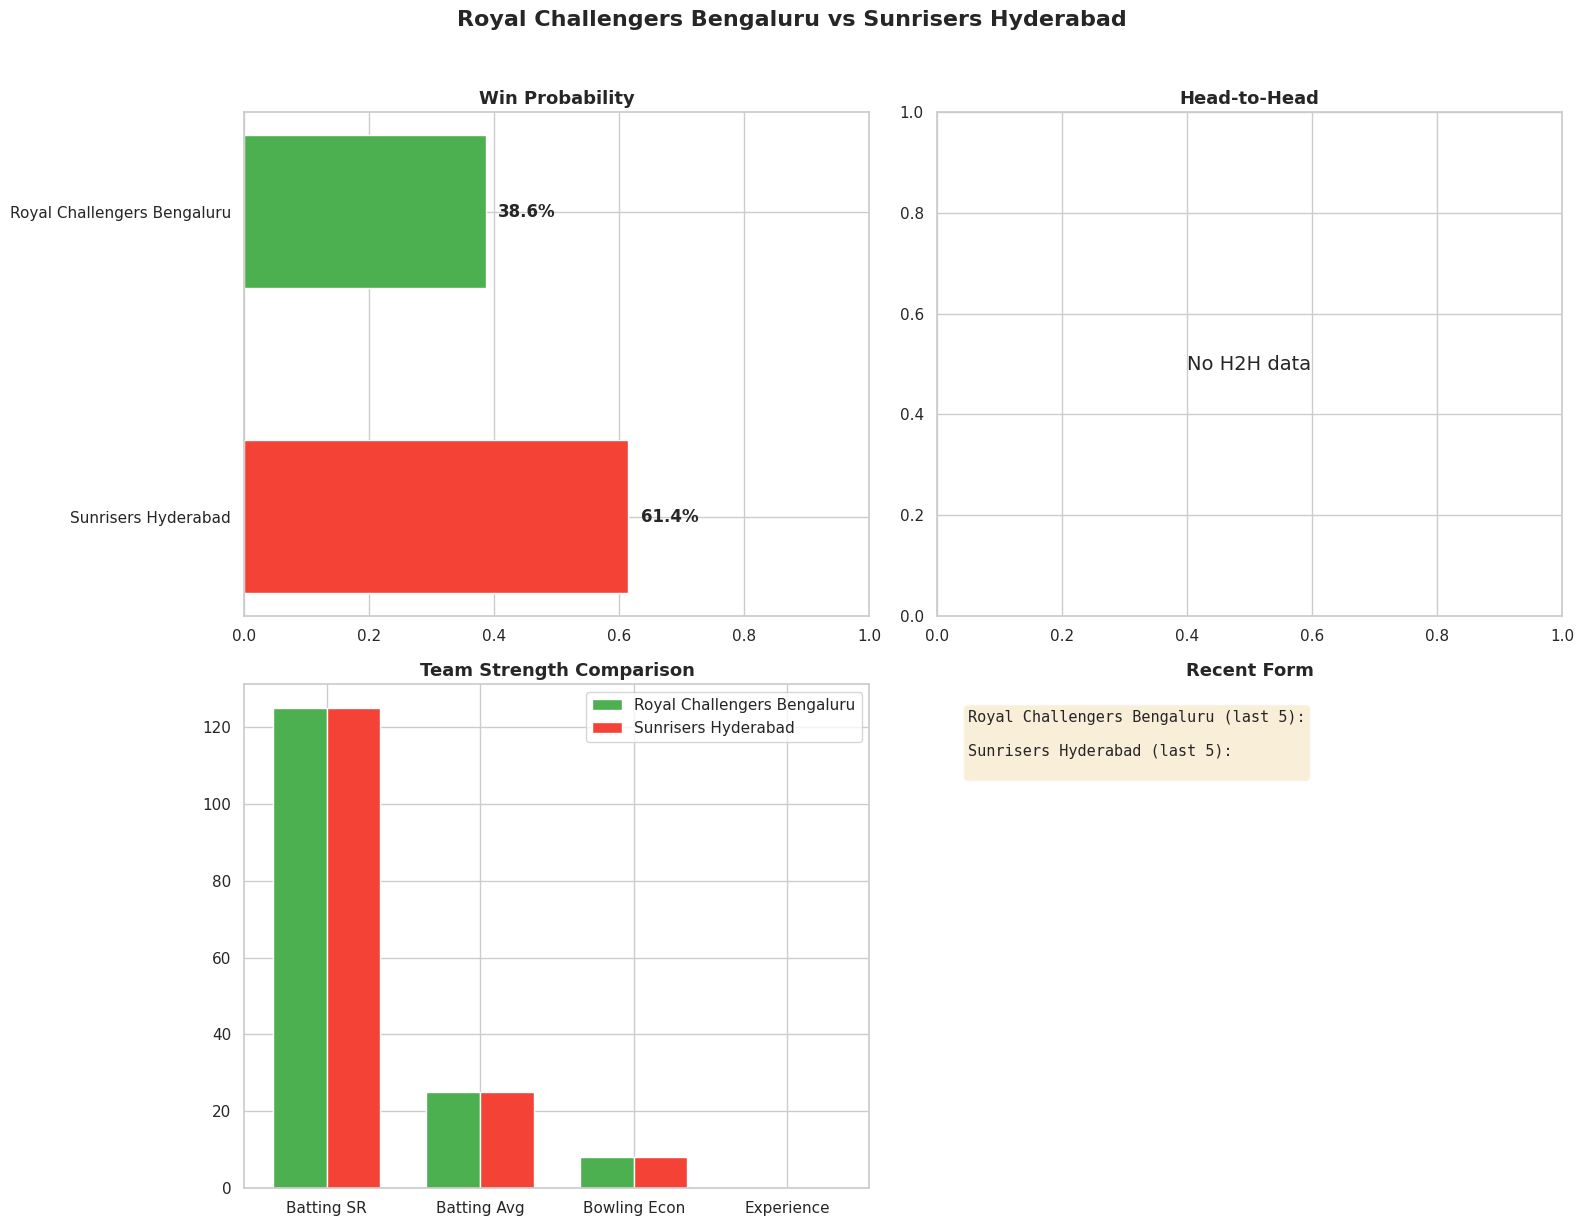

In [6]:
# --- Detailed Analysis ---

# Win probability bar
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Win probability
ax = axes[0, 0]
bars = ax.barh([TEAM2, TEAM1], [team2_win_prob, team1_win_prob],
               color=['#f44336', '#4CAF50'], edgecolor='white', height=0.5)
ax.set_xlim(0, 1)
ax.set_title('Win Probability', fontsize=13, fontweight='bold')
for bar, val in zip(bars, [team2_win_prob, team1_win_prob]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontweight='bold', fontsize=12)

# 2. Head-to-head
ax = axes[0, 1]
h2h_t1, h2h_t2, h2h_total = get_h2h(TEAM1, TEAM2)
if h2h_total > 0:
    ax.pie([h2h_t1, h2h_t2], labels=[f'{TEAM1}\n({h2h_t1})', f'{TEAM2}\n({h2h_t2})'],
           autopct='%1.0f%%', colors=['#4CAF50', '#f44336'], startangle=90,
           textprops={'fontsize': 11})
    ax.set_title(f'Head-to-Head ({h2h_total} matches)', fontsize=13, fontweight='bold')
else:
    ax.text(0.5, 0.5, 'No H2H data', ha='center', va='center', fontsize=14)
    ax.set_title('Head-to-Head', fontsize=13, fontweight='bold')

# 3. Team strength comparison
ax = axes[1, 0]
metrics = ['Batting SR', 'Batting Avg', 'Bowling Econ', 'Experience']
t1_vals = [t1_str['avg_batting_sr'], t1_str['avg_batting_avg'],
           t1_str['avg_bowling_econ'], t1_str['total_experience']]
t2_vals = [t2_str['avg_batting_sr'], t2_str['avg_batting_avg'],
           t2_str['avg_bowling_econ'], t2_str['total_experience']]
# Normalize for comparison
t1_norm = [v / max(v1, v2) if max(v1, v2) > 0 else 0.5 for v, v1, v2 in zip(t1_vals, t1_vals, t2_vals)]
t2_norm = [v / max(v1, v2) if max(v1, v2) > 0 else 0.5 for v, v1, v2 in zip(t2_vals, t1_vals, t2_vals)]

x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, t1_vals, width, label=TEAM1, color='#4CAF50', edgecolor='white')
ax.bar(x + width/2, t2_vals, width, label=TEAM2, color='#f44336', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_title('Team Strength Comparison', fontsize=13, fontweight='bold')

# 4. Recent form
ax = axes[1, 1]
_, t1_results = get_team_form(TEAM1, n=5)
_, t2_results = get_team_form(TEAM2, n=5)
form_text = f"{TEAM1} (last 5):\n"
for r in t1_results:
    form_text += f"  {'\u2705' if r.startswith('W') else '\u274c'} {r}\n"
form_text += f"\n{TEAM2} (last 5):\n"
for r in t2_results:
    form_text += f"  {'\u2705' if r.startswith('W') else '\u274c'} {r}\n"
ax.text(0.05, 0.95, form_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_title('Recent Form', fontsize=13, fontweight='bold')
ax.axis('off')

plt.suptitle(f'{TEAM1} vs {TEAM2}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# --- Venue Analysis ---
vs = get_venue_stats(VENUE, TEAM1, TEAM2)
print(f'\n=== Venue Analysis: {VENUE} ===')
print(f'Total matches at venue: {vs["total_matches"]}')
print(f'Bat first win %: {vs["bat_first_win_pct"]:.1%}')
print(f'Chase win %: {1 - vs["bat_first_win_pct"]:.1%}')
print(f'{TEAM1} win % at venue: {vs["team1_venue_pct"]:.1%}')
print(f'{TEAM2} win % at venue: {vs["team2_venue_pct"]:.1%}')
print(f'Toss winner win % at venue: {get_toss_venue_pct(VENUE):.1%}')

# New player impact
print(f'\n=== Squad Composition ===')
print(f'{TEAM1}: {t1_str["total_experience"]} total IPL caps, {t1_str["new_player_count"]} new players')
print(f'{TEAM2}: {t2_str["total_experience"]} total IPL caps, {t2_str["new_player_count"]} new players')


=== Venue Analysis: M Chinnaswamy Stadium ===
Total matches at venue: 65
Bat first win %: 43.1%
Chase win %: 56.9%
Royal Challengers Bengaluru win % at venue: 50.0%
Sunrisers Hyderabad win % at venue: 50.0%
Toss winner win % at venue: 53.8%

=== Squad Composition ===
Royal Challengers Bengaluru: 0 total IPL caps, 11 new players
Sunrisers Hyderabad: 0 total IPL caps, 11 new players


In [8]:
# --- Feature Contribution (which factors matter most for this prediction) ---
importances = model.feature_importances_
feat_values = X.values[0]
contribution = importances * np.abs(feat_values)

contrib_df = pd.DataFrame({
    'Feature': feature_cols,
    'Value': feat_values,
    'Importance': importances,
    'Contribution': contribution
}).sort_values('Contribution', ascending=False)

print('\n=== Top 10 Contributing Factors ===')
for i, row in contrib_df.head(10).iterrows():
    print(f'  {row["Feature"]:35s} = {row["Value"]:8.2f}  (importance: {row["Importance"]:.3f})')


=== Top 10 Contributing Factors ===
  season                              =  2026.00  (importance: 0.034)
  team2_recent_batting_sr             =   125.00  (importance: 0.036)
  team1_recent_batting_sr             =   125.00  (importance: 0.036)
  team1_avg_batting_sr                =   125.00  (importance: 0.036)
  team2_avg_batting_sr                =   125.00  (importance: 0.035)
  team1_avg_batting_avg               =    25.00  (importance: 0.033)
  team2_avg_batting_avg               =    25.00  (importance: 0.031)
  team1_avg_bowling_sr                =    20.00  (importance: 0.039)
  team2_avg_bowling_sr                =    20.00  (importance: 0.033)
  team1_new_player_count              =    11.00  (importance: 0.029)


## 4. Batch Predict (Full Matchday)

Add multiple matches below to predict an entire match day.

In [ ]:
# ============================================================
# EDIT: Add all matches for the day
# ============================================================

matchday = [
    {
        'team1': 'Kolkata Knight Riders',
        'team2': 'Royal Challengers Bengaluru',
        'venue': 'Eden Gardens, Kolkata',
        'toss_winner': 'Kolkata Knight Riders',
        'toss_decision': 'field',
    },
    # Add more matches here:
    # {
    #     'team1': 'Mumbai Indians',
    #     'team2': 'Chennai Super Kings',
    #     'venue': 'Wankhede Stadium, Mumbai',
    #     'toss_winner': 'Chennai Super Kings',
    #     'toss_decision': 'bat',
    # },
]

# ============================================================

In [ ]:
# Run batch predictions
results = []
for match in matchday:
    X, _, _, _ = build_features(
        match['team1'], match['team2'], match['venue'],
        match['toss_winner'], match['toss_decision']
    )
    proba = model.predict_proba(X)[0]
    t1_prob, t2_prob = proba[1], proba[0]
    winner = match['team1'] if t1_prob > 0.5 else match['team2']
    conf = max(t1_prob, t2_prob)

    results.append({
        'Match': f"{match['team1']} vs {match['team2']}",
        'Venue': match['venue'],
        'Toss': f"{match['toss_winner']} ({match['toss_decision']})",
        'Predicted Winner': winner,
        'Confidence': f'{conf:.1%}',
        f"{match['team1']} %": f'{t1_prob:.1%}',
        f"{match['team2']} %": f'{t2_prob:.1%}',
    })

results_df = pd.DataFrame(results)
print('\n=== MATCHDAY PREDICTIONS ===')
display(results_df)

## 5. Update Dataset After Matches

After matches are played, add the results here so future predictions use updated data.

In [ ]:
# ============================================================
# EDIT: Add completed match results
# Run this cell to append to matches.csv
# ============================================================

new_matches = [
    # Example (uncomment and edit):
    # {
    #     'id': 10001,  # unique id, increment from last match
    #     'city': 'Kolkata',
    #     'date': '2026-03-28',
    #     'season': 2026,
    #     'match_number': 1,
    #     'team1': 'Kolkata Knight Riders',
    #     'team2': 'Royal Challengers Bengaluru',
    #     'venue': 'Eden Gardens, Kolkata',
    #     'toss_winner': 'Kolkata Knight Riders',
    #     'toss_decision': 'field',
    #     'winner': 'Kolkata Knight Riders',
    #     'result': 'runs',
    #     'win_by_runs': 25,
    #     'win_by_wickets': 0,
    #     'player_of_match': 'Andre Russell',
    # },
]

if len(new_matches) > 0:
    new_df = pd.DataFrame(new_matches)
    existing = pd.read_csv(DATASET_DIR / 'matches.csv')
    updated = pd.concat([existing, new_df], ignore_index=True)
    updated.to_csv(DATASET_DIR / 'matches.csv', index=False)
    print(f'Added {len(new_matches)} match(es). Total matches: {len(updated)}')
    print('Reload the notebook (Kernel > Restart) to use updated data.')
else:
    print('No new matches to add. Edit the cell above with match results.')

In [ ]:
# Quick reference: IPL 2026 Teams
print('IPL 2026 Teams:')
for i, team in enumerate(IPL_2026_TEAMS, 1):
    print(f'  {i:2d}. {team}')